In [2]:
import muspan as ms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import networkx as nx

from roifile import roiread

print("Packages loaded successfully!")

Packages loaded successfully!


In [3]:
nodes_list=pickle.load(open(f"results/skeleton/nodes_list.txt","rb"))
adj_list=pickle.load(open(f"results/skeleton/adj_list.txt","rb"))

nodes = nodes_list[3]
adj = adj_list[3]

In [16]:
rois = roiread('data/hh5RoiSet.zip')
domain = ms.domain("test_domain2")
n_limit = 10000
n=0
for i in rois:
    if n<n_limit:
        try:
            #shape = [4806,5288] + [1,-1] * i.integer_coordinates + [i.left, -i.top]
            coords = i.coordinates()
            shape = [4806,5288] + [1,-1] * (coords + np.roll(coords,1,axis=0) + np.roll(coords,-1,axis=0) + np.roll(coords,-2,axis=0) + np.roll(coords,2,axis=0))/5
            shape2 = [4806,5288] + [1,-1] * coords 
            domain.add_shapes([shape2],"original")
            domain.add_shapes([shape],"rolling av")
            

        except Exception as e:
            print(e)
            print(i.coordinates())
        n=n+1
    

(<Figure size 1000x800 with 2 Axes>, <Axes: >)

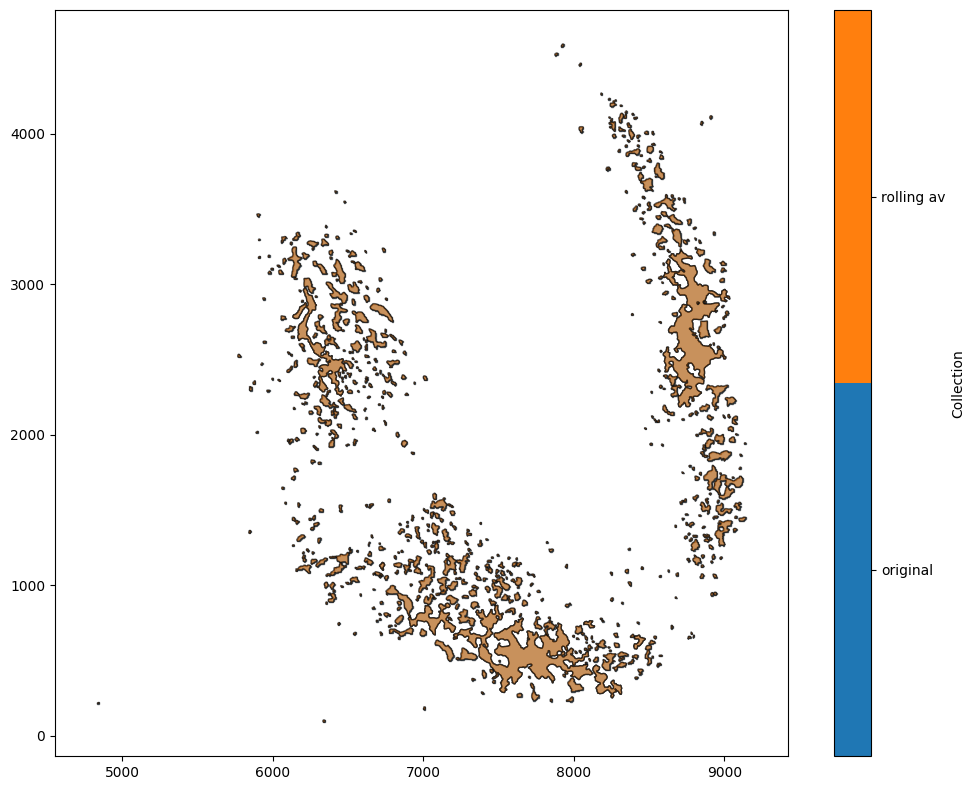

In [17]:
ms.visualise.visualise(domain)

[np.float64(0.8710219343270934), np.float64(0.9248732284904536), np.float64(0.7576393474949666), np.float64(0.8674722007904857), np.float64(0.9409498770800471), np.float64(0.425084002854402), np.float64(0.9501068908781757), np.float64(0.8229309514453403), np.float64(0.587080122245667), np.float64(0.9500292447723457), np.float64(0.7920015190227963), np.float64(0.8863125260588897), np.float64(0.9596039855276612), np.float64(0.6495535102046044), np.float64(0.7429129005726601), np.float64(0.8242035484914556), np.float64(0.3503272058393318), np.float64(0.6546160311313332), np.float64(0.7259147294816835), np.float64(0.45164461148194024), np.float64(0.6192277098159185), np.float64(0.824287976992961), np.float64(0.8289722384094902), np.float64(0.9290466706546916), np.float64(0.6909784879156081), np.float64(0.8953875145902982), np.float64(0.6342833020293981), np.float64(0.9352508680007324), np.float64(0.7977285605110889), np.float64(0.9335036439140418), np.float64(0.9565479726204961), np.float6

{'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x1ab258e2290>],
 'cmaxes': <matplotlib.collections.LineCollection at 0x1ab2b6bbc50>,
 'cmins': <matplotlib.collections.LineCollection at 0x1ab2d969110>,
 'cbars': <matplotlib.collections.LineCollection at 0x1ab34f222d0>}

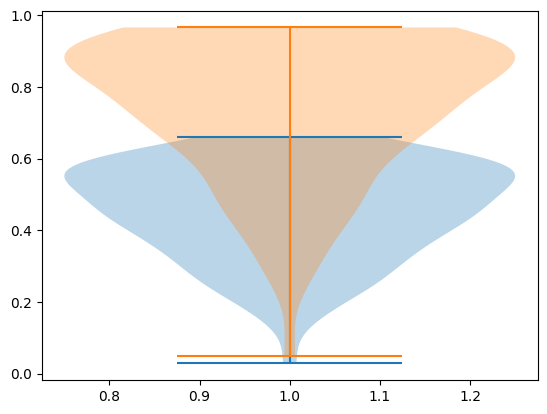

In [6]:
test = ms.query.get_collections(domain)
test = ms.query.query(domain,("collection",),"is","original")
circle = ms.geometry.circularity(domain,population=test)
plt.violinplot(circle[0])

test = ms.query.query(domain,("collection",),"is","rolling av")
circle = ms.geometry.circularity(domain,population=test)

print(circle[0])
plt.violinplot(circle[0])

In [18]:
test = ms.query.query(domain,("collection",),"is","rolling av")
circle = ms.geometry.circularity(domain,population=test)
for i in range(len(circle[0])):
    if circle[0][i]<0.5:
        print(i)
        domain.add_objects_to_collection(add_collection_to=i, collection_name="low circularity")

5
16
19
32
38
41
47
53
59
71
76
83
85
95
104
106
125
129
142
143
146
147
154
160
165
166
174
175
191
204
205
226
227
235
239
242
252
257
266
268
269
273
281
282
304
305
311
318
326
333
334
336
337
338
341
353
358
373
383
388
398
400
402
425
426
433
434
440
450
455
456
457
458
461
472
485
487
488
490
494
503
520
530
538
540
543
544
550
557
558
566
575
584
589
590
593
598
608
610


(<Figure size 1000x800 with 2 Axes>, <Axes: >)

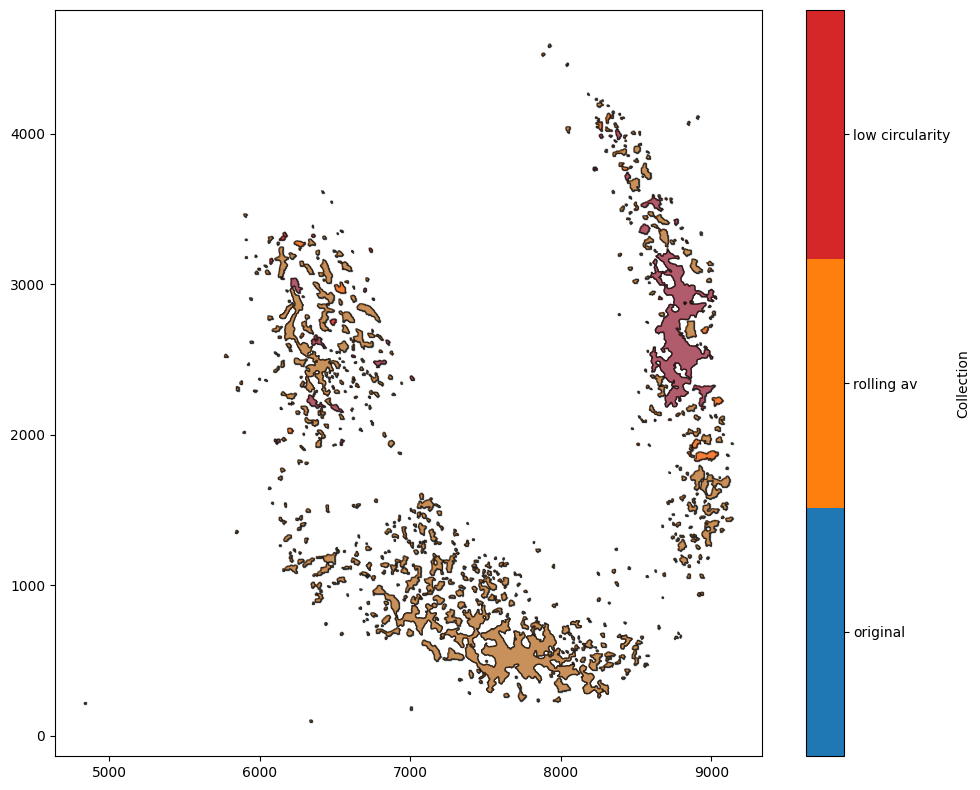

In [19]:
ms.visualise.visualise(domain)

(<Figure size 1000x800 with 2 Axes>, <Axes: >)

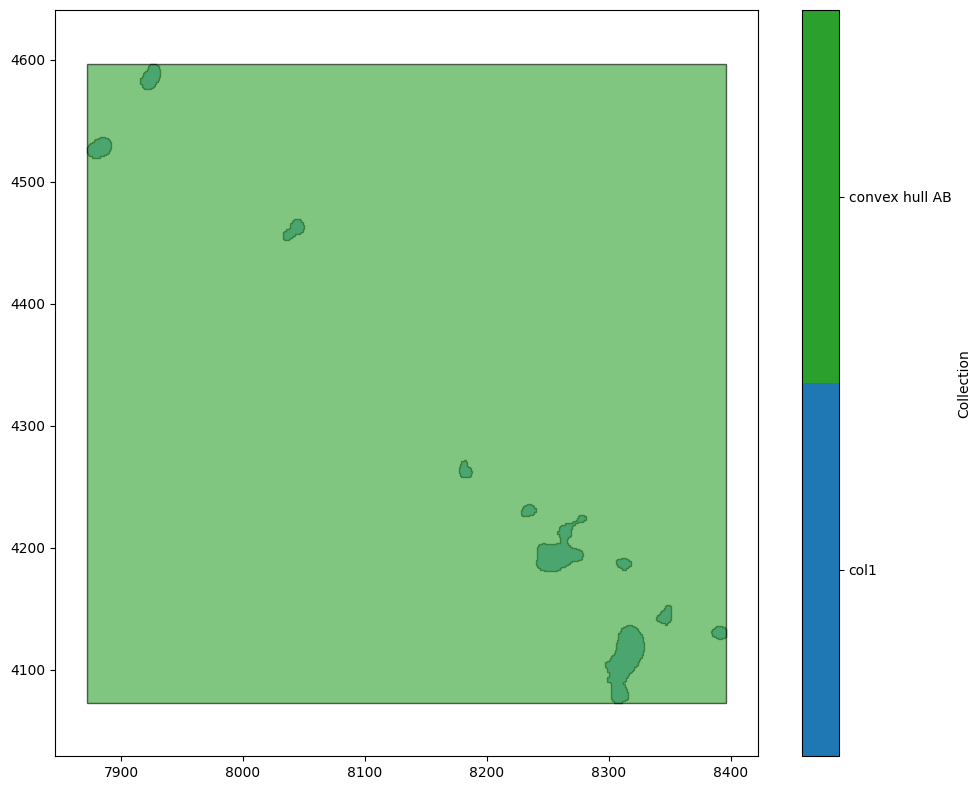

In [70]:
test = ms.query.get_collections(domain)[1]
domain.convert_objects(
    population=test,
    collection_name='convex hull AB',
    object_type='shape',
    conversion_method='convex hull'
)

ms.visualise.visualise(domain)

In [73]:
dom.convert_objects(
    population=('Collection', 'col1'),
    object_type='point',
    conversion_method='centroids',
    collection_name='Cell centroids',
    inherit_collections=False
)


ms.networks.generate_network(
    dom,
    network_name='prox network centroids 10',
    network_type='Proximity',
    objects_as_nodes=('collection', 'col1'),
    max_edge_distance=10,
    min_edge_distance=0
)

ms.networks.generate_network(
    dom,
    network_name='prox network centroids 30',
    network_type='Proximity',
    objects_as_nodes=('collection', 'col1'),
    max_edge_distance=30,
    min_edge_distance=0
)

ms.networks.generate_network(
    dom,
    network_name='prox network centroids 50',
    network_type='Proximity',
    objects_as_nodes=('collection', 'col1'),
    max_edge_distance=50,
    min_edge_distance=0
)





(<Figure size 1000x800 with 2 Axes>, <Axes: >)

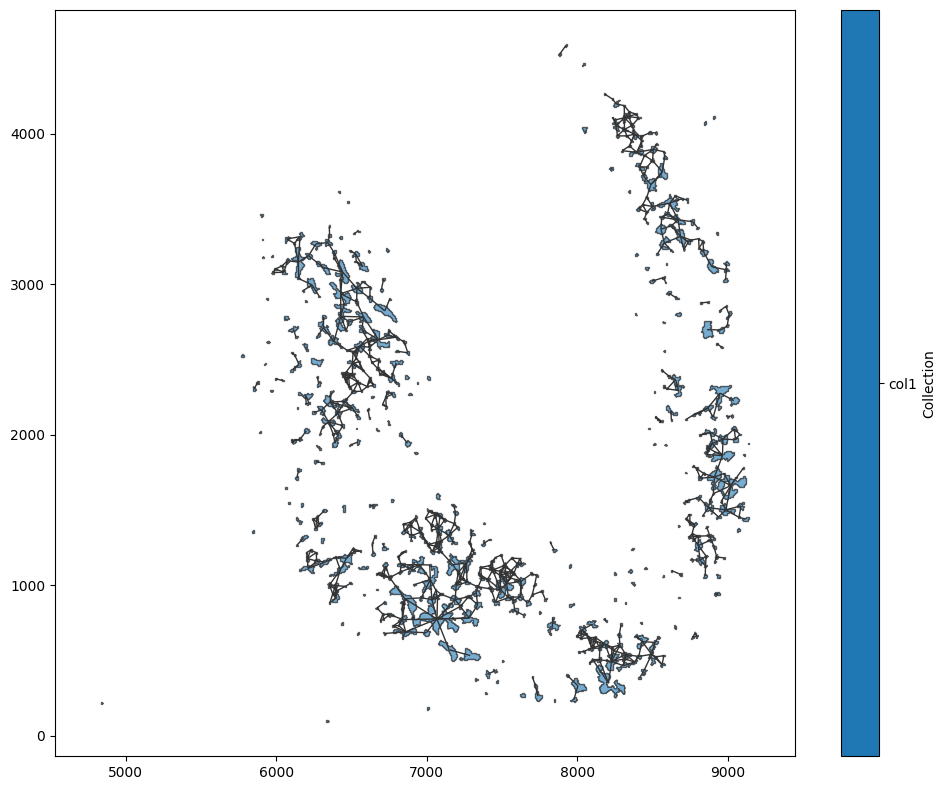

In [83]:
#fig, ax = plt.subplots(1, 3, figsize=(25, 6), gridspec_kw={'width_ratios': [1, 1, 1.8]})
#fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# ms.visualise.visualise_network(
#     dom,
#     network_name='prox network centroids 10',
#     ax=ax[0],
#     edge_cmap='viridis',
#     edge_vmin=0,
#     edge_vmax=50,
#     add_cbar=False,
#     visualise_kwargs=dict(objects_to_plot=('collection', 'col1'), marker_size=15)
# )


# # Plot the proximity network with 30μm max distance
# ax[1].set_title('Proximity network: 30μm max distance')
# ms.visualise.visualise_network(
#     dom,
#     network_name='prox network centroids 30',
#     ax=ax[1],
#     edge_cmap='viridis',
#     edge_vmin=0,
#     edge_vmax=50,
#     add_cbar=False,
#     visualise_kwargs=dict(objects_to_plot=('collection', 'col1'), marker_size=15)
# )

# # Plot the proximity network with 50μm max distance
#ax.set_title('Proximity network: 50μm max distance')
ms.visualise.visualise_network(
    dom,
    network_name='prox network centroids 50',
    #ax=ax,
    edge_cmap='viridis',
    edge_vmin=0,
    edge_vmax=50,
    visualise_kwargs=dict(objects_to_plot=('collection', 'col1'), marker_size=15)
)